In [18]:
path = "/lustre/LHCb/carlos.arenas/data/v009_pb-pb-pmu0.0018-fn0k-fc0-ww3_inelastic_none_1_1e6.hepmc"
# path = "/lustre/LHCb/carlos.arenas/data/v009_pb-pb-pmu0.0018-fn0k-fc0-ww3_inelastic_none_1_1e6.hepmc"

event_nr = 1

In [4]:
import sys
sys.path.insert(0, "cobra/src")           # so Python can find the cobra package
from cobra import load_detector_from_yaml

detector = load_detector_from_yaml("/lustre/LHCb/carlos.arenas/cobra/config/codex-beta.yaml")

In [41]:
import pyhepmc
import numpy as np
from cobra import StripDecoder
from cobra.geometry import transform_surface
from cobra.geometry import strip_to_global_position

def strip_points(detector, strips):
    points = []
    for module_id in {int(r[0]) for r in strips}:       # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = [r for r in strips if int(r[0]) == module_id and int(r[1]) == slot]
            phi_strips = [int(r[2]) for r in here if int(r[4]) == 0]
            eta_strips = [int(r[2]) for r in here if int(r[4]) == 1]
            singlet = detector.singlets[module.singlet_ids[slot]]
            for phi in phi_strips:
                for eta in eta_strips:
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)
                    points.append(point)
                    # print(phi, eta, point)

    return [np.array(points_module) for points_module in points]

def strip_points_module_singlet(detector, strips, row_ids):
    points = []
    module_singlets = []
    new_row_ids = []

    # print(f"lens: {len(strips)}, {len(row_ids)}")

    for module_id in {int(r[0]) for r in strips}:       # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = {row_ids[i]: strips[i] for i in range(len(strips)) if int(strips[i][0]) == module_id and int(strips[i][1]) == slot}
            phi_strips = {row_id: int(strip[2]) for row_id, strip in here.items() if int(strip[4]) == 0}
            eta_strips = {row_id: int(strip[2]) for row_id, strip in here.items() if int(strip[4]) == 1}
            singlet = detector.singlets[module.singlet_ids[slot]]
            for row_id_phi, phi in phi_strips.items():
                for row_id_eta, eta in eta_strips.items():
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)
                    points.append(point)
                    module_singlets.append([module_id, slot])

                    new_row_ids.append([row_id_phi, row_id_eta])
                    
    return np.array(points), module_singlets, new_row_ids

def get_hit_points(event_nr):
    with pyhepmc.open(path) as f:

        it = iter(f)
        for i in range(event_nr):
            try:
                next(it)
            except StopIteration:
                print("Se acabaron los eventos")
                break

        event = next(it)

    rows = []
    raw_banks_id = []
    for key, value in event.attributes.items():
        if key.startswith("RawBank_"):
            raw_bank_id = key.split("_")[-1]
            module, strip, time0, time1 = [int(x) for x in str(value).split()]

            rows.append([0, module, strip, time0, time1])           # 0 = sourceID placeholder
            raw_banks_id.append(int(raw_bank_id))

    raw_banks = np.array(rows, dtype=np.int16)

    strips = []
    new_raw_banks_id = []

    for i, raw_bank in enumerate(raw_banks):
        current_strips = StripDecoder()._process(np.array([raw_bank]))
        for strip in current_strips:
            strips.append(strip)
            new_raw_banks_id.append(raw_banks_id[i])

    raw_banks_id = new_raw_banks_id

    # strips = StripDecoder()._process(raw_banks)

    points, module_singlets, new_raw_banks_id = strip_points_module_singlet(detector, strips, raw_banks_id)

    return points, module_singlets, new_raw_banks_id

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_detector(ax, view = "front", zoom = "zoom_in"):
    for module in detector.modules.values():
        corners = np.vstack([transform_surface(detector, module, detector.singlets[s]) for s in module.singlet_ids])
        lo, hi = corners.min(axis=0), corners.max(axis=0)
        if view == "front":
            ax.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1], facecolor="lightgreen", alpha=0.3))
        elif view == "side":
            ax.add_patch(plt.Rectangle((lo[0], lo[2]), hi[0] - lo[0], hi[2] - lo[2], facecolor="lightgreen", alpha=0.3))

    ax.set_xlabel("x [m]")
    ax.set_box_aspect(1)

    if view == "front":
        ax.set_ylabel("y [m]");
        if zoom == "zoom_in":
            ax.set_xlim(left= 29, right= 33)
            ax.set_ylim(bottom= -6, top= -3)
        elif zoom == "zoom_medium":
            ax.set_xlim(left= 25, right= 33)
            ax.set_ylim(bottom= -6, top= -2)
        elif zoom == "zoom_out":
            ax.set_xlim(left=-10, right=32)
            ax.set_ylim(bottom=-10, top=25)
        elif zoom == "zooom_in":
            ax.set_xlim(left= 29.7, right= 29.9)
            ax.set_ylim(bottom= -5.3, top= -5)
    if view == "side":
        ax.set_ylabel("z [m]");
        if zoom == "zoom_out":
            ax.set_xlim(left=-10, right=32)
            ax.set_ylim(bottom=-10, top=25)
        elif zoom == "zoom_in":
            ax.set_xlim(left=29, right=33)
            ax.set_ylim(bottom=7, top=11)

In [7]:
def cov(X, Y):
    return sum((X - np.mean(X))*(Y - np.mean(Y)))

def lineal_regression(X, Y):
    # lmq -> y = mx + n
    m = cov(X,Y)/cov(X,X)
    n = np.mean(Y) - m*np.mean(X)

    err = Y - m*X - n
    R = 1 - np.dot(err, err)/cov(Y, Y)

    return m, n, R

In [59]:
hit_points, module_singlets, raw_banks_id = get_hit_points(event_nr)

print(f"Hay: {len(hit_points)} puntos")

# sort points by module, singlet:
sorted_points_id = []
modules = {module_singlet[0] for module_singlet in module_singlets}
for module in modules:
    sorted_points_id.append([[],[],[]])
    for i, P in enumerate(hit_points):
        if module_singlets[i][0] == module:
            sorted_points_id[-1][module_singlets[i][1]].append(i)

Hay: 47 puntos


In [69]:
def group_inside_modules(sorted_points_id):
    global hit_points

    clusters = []
    min_distance = 0.0015
    for module_points in sorted_points_id:
        module_selected_points = [0]*sum([len(x) for x in module_points])

        for i, id1 in enumerate(module_points[0]):
            if not module_selected_points[i]:
                P1 = hit_points[id1]

                d2_min = min_distance
                for j, id2 in enumerate(module_points[1]):
                    if not module_selected_points[j + len(module_points[0])]:
                        P2 = hit_points[id2]

                        d2_ij = np.dot((P2 - P1), (P2 - P1))
                        if d2_ij < d2_min:
                            d2_min = d2_ij

                    if d2_min < min_distance:
                        d2_min = min_distance
                        for k, id3 in enumerate(module_points[2]):
                            if not module_selected_points[k + len(module_points[0]) + len(module_points[1])]:
                                P3 = hit_points[id3]

                                d2_ij = np.dot((P3 - P2), (P3 - P2))
                                if d2_ij < d2_min:
                                    d2_min = d2_ij

                                if d2_min < min_distance:
                                    # print("Hola", i, j + len(module_points[0]), k + len(module_points[0]) + len(module_points[1]))

                                    X = np.array([P1, P2, P3])
                                    m, n, R = lineal_regression(X[:,0], X[:,1])

                                    if R > 0.7:
                                        clusters.append([id1, id2, id3])
                                        module_selected_points[i] = 1
                                        module_selected_points[j + len(module_points[0])] = 1
                                        module_selected_points[k + len(module_points[0]) + len(module_points[1])] = 1

                                    break
    return clusters

In [ ]:
def group_inside_modules_old(sorted_points):
    clusters = []
    min_distance = 0.0015
    for module_points in sorted_points:
        module_selected_points = [0]*sum([len(x) for x in module_points])

        for i, P1 in enumerate(module_points[0]):
            if not module_selected_points[i]:

                d2_min = min_distance
                for j, P2 in enumerate(module_points[1]):
                    if not module_selected_points[j + len(module_points[0])]:
                        d2_ij = np.dot((P2 - P1), (P2 - P1))
                        if d2_ij < d2_min:
                            d2_min = d2_ij

                    if d2_min < min_distance:
                        d2_min = min_distance
                        for k, P3 in enumerate(module_points[2]):
                            if not module_selected_points[k + len(module_points[0]) + len(module_points[1])]:
                                d2_ij = np.dot((P3 - P2), (P3 - P2))
                                if d2_ij < d2_min:
                                    d2_min = d2_ij

                                if d2_min < min_distance:
                                    # print("Hola", i, j + len(module_points[0]), k + len(module_points[0]) + len(module_points[1]))

                                    X = np.array([P1, P2, P3])
                                    m, n, R = lineal_regression(X[:,0], X[:,1])

                                    if R > 0.7:
                                        clusters.append(X)
                                        module_selected_points[i] = 1
                                        module_selected_points[j + len(module_points[0])] = 1
                                        module_selected_points[k + len(module_points[0]) + len(module_points[1])] = 1

                                    break
    return clusters

6


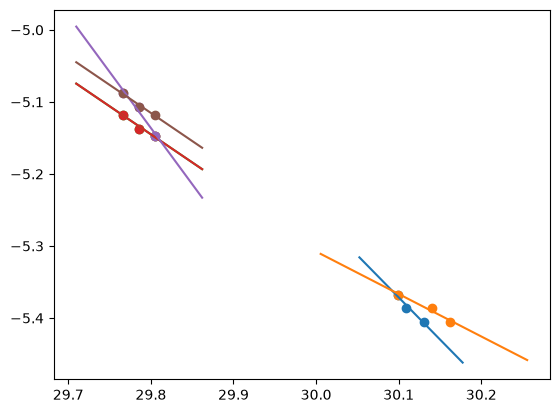

In [71]:
# n_tries = 100
"""
for module_points in sorted_points:
    flattened_points = sum(module_points, [])
    selected_points = [0]*len(flattened_points)

    for i, P in enumerate(flattened_points):
        if not selected_points[i]:
            d2_min = 1
            for j, Q in enumerate(flattened_points[i+1:]):
                d2_ij = np.dot((Q - P), (Q - P))

                if d2_ij < d2_min: d2_min = d2_ij
"""
                
clusters = group_inside_modules(sorted_points_id)

# print(selected_points)

for cluster in clusters:
    X = np.array([hit_points[point_id] for point_id in cluster])
    plt.scatter(X[:,0], X[:,1])

    m, n, R = lineal_regression(X[:,0], X[:,1])

    a = min(X[:,0])
    b = max(X[:,0])

    e = 1.5*(b-a)
    a -= e
    b += e

    plt.plot([a,b], m*np.array([a,b]) + n)

print(len(clusters))

# plt.scatter(X[:,0], X[:,1])
plt.show()

# print(len(module_points))


In [37]:
with open(path, "r") as file:
    lines = file.readlines()

event_lines = []
for i, line in enumerate(lines):
    values = line.split(" ")

    if values[0] == "E":
        event_id = int(values[1])
        event_lines.append([event_id, i])

event_lines.append([0, len(lines)])

print(f"Hay {len(event_lines) - 1} eventos")

Hay 172 eventos


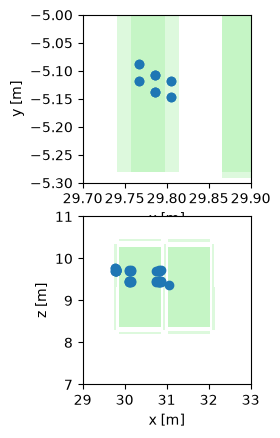

In [61]:
particle_links = {}
raw_banks = {}
raw_banks_particles = {}

global event_nr
for line in lines[event_lines[event_nr][1]:event_lines[event_nr + 1][1]]:
    values = line.split()

    if values[0] == "A":
        if values[2] == "RawBankLinks":
            particle_id = int(values[1])
            particle_links[particle_id] = [int(x) for x in values[3:]]

            for x in values[3:]:
                raw_banks_particles[abs(int(x))] = particle_id

        elif values[2].startswith("RawBank_"):
            raw_bank_id = int(values[2].split("_")[-1])
            raw_bank = [int(x) for x in values[3:]]

            raw_banks[raw_bank_id] = raw_bank

fig, axs = plt.subplots(2)
plot_detector(axs[0], zoom = "zooom_in")
axs[0].scatter(hit_points[:,0], hit_points[:,1])

plot_detector(axs[1], view = "side", zoom = "zoom_in")
axs[1].scatter(hit_points[:,0], hit_points[:,2])
plt.show()

In [72]:
# Match points with particles
# points[i] <-> points_particle[i]

points_particle = []
for phi_id, eta_id in raw_banks_id:
    particle_id = raw_banks_particles[phi_id]
    if particle_id == raw_banks_particles[eta_id]:
        points_particle.append(particle_id)
    else:
        points_particle.append(None)

In [ ]:
ef_counter = 0
total_counter = 0

for cluster in clusters:
    same_particle = True
    for point_id in cluster[1:]:
        if points_particle[point_id] != points_particle[cluster[0]]:
            same_particle = False

    if same_particle:
        ef_counter += 1
    total_counter += 1

print(ef_counter, total_counter)

5 6


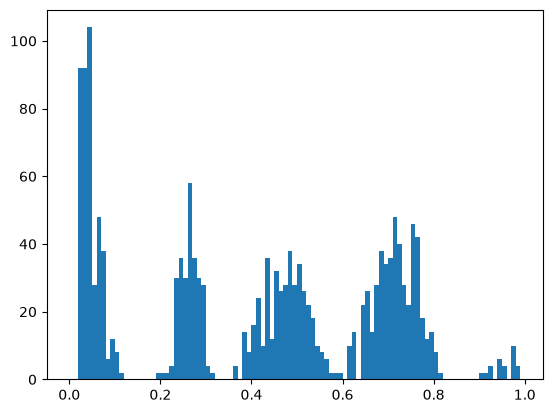

In [75]:
distances = []

for i, P in enumerate(hit_points):
    for j, Q in enumerate(hit_points):
        if i != j:
            PQ = Q - P
            d = np.sqrt(np.dot(PQ,PQ))
            distances.append(d)

fig, ax = plt.subplots()
ax.hist(distances, bins = np.arange(0, 1, 0.01))
plt.show()

In [ ]:
sorted_points = points[points[:, 0].argsort()[::-1]] # Ordena de mayor a menor

print(sorted_points)



[[31.047735   -5.421545    9.37913125]
 [30.859305   -5.386615    9.42850625]
 [30.859305   -5.386615    9.72538125]
 [30.859305   -5.386615    9.45819375]
 [30.849305   -5.367565    9.70569375]
 [30.849305   -5.367565    9.46819375]
 [30.849305   -5.367565    9.43850625]
 [30.828055   -5.386615    9.72538125]
 [30.828055   -5.386615    9.42850625]
 [30.828055   -5.386615    9.45819375]
 [30.818055   -5.367565    9.70569375]
 [30.818055   -5.367565    9.43850625]
 [30.818055   -5.367565    9.46819375]
 [30.786805   -5.367565    9.70569375]
 [30.786805   -5.367565    9.43850625]
 [30.786805   -5.367565    9.46819375]
 [30.755555   -5.367565    9.70569375]
 [30.755555   -5.367565    9.43850625]
 [30.755555   -5.367565    9.46819375]
 [30.161805   -5.405665    9.70569375]
 [30.140555   -5.386615    9.45819375]
 [30.140555   -5.386615    9.42850625]
 [30.140555   -5.386615    9.72538125]
 [30.130555   -5.367565    9.46819375]
 [30.130555   -5.367565    9.43850625]
 [30.130555   -5.367565  